# P1/P2 Visualizer — Exploring the Synthetic Household Population

Visual exploration of the matched synthetic population (`synthetic_population_matched.parquet`):
income-quintile **archetypes**, balance sheets, financial-inclusion flags, bivariate structure, and a
data-driven **clustering** check of whether the five income quintiles capture the population's structure.

All monetary values are **2017 Rands**. Statistics are **survey-weighted** (`w5_wgt`) unless noted.
See [`../OVERVIEW.md`](../OVERVIEW.md).

## 1. Setup & load

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

def find_root(start=Path.cwd()):
    for d in [start, *start.parents]:
        if (d / "data" / "processed" / "synthetic_population_matched.parquet").exists():
            return d
    raise FileNotFoundError("run P2 first")
ROOT = find_root()
df = pd.read_parquet(ROOT / "data/processed/synthetic_population_matched.parquet")

QORDER = ["Q1", "Q2", "Q3", "Q4", "Q5"]
df["income_quintile"] = pd.Categorical(df["income_quintile"], categories=QORDER, ordered=True)
flags = ["banked", "credit_access_formal", "informal_finance", "savings_product"]
df[flags] = df[flags].astype(int)
df["dsti"] = (df["monthly_trad_repayment"] / df["w5_hhincome"].replace(0, np.nan)).fillna(0)

QCOL = {"Q1": "#762a83", "Q2": "#af8dc3", "Q3": "#7fbf7b", "Q4": "#1b7837", "Q5": "#08519c"}
def wmean(s, w): return np.average(s, weights=w)
print("households:", len(df), "| weighted:", f"{df.w5_wgt.sum():,.0f}", "| cols:", df.shape[1])
df.head(3)

households: 10841 | weighted: 18,670,046 | cols: 31


,w5_hhid,w5_wgt,w5_hhsizer,province,w5_hhincome,income_pc,income_quintile,income_source,expenditure_total,expenditure_committed,...,savings_product,K7,G10,G11,G12,G13,G14,repay_uncapped,monthly_trad_repayment,dsti
0,500000,1386.3219,2.0,Eastern Cape,58752.0000,29376.00000,Q5,WAGE,39536.0,3000.0,...,1,Refused,No,No,No,No,No,53.37152,53.37152,0.000908
1,500001,2462.3228,1.0,Limpopo,2231.8245,2231.82450,Q3,OTHER,985.0,869.0,...,0,,No,No,No,No,No,0.00000,0.00000,0.000000
2,500002,980.3248,4.0,Limpopo,1598.5950,399.64875,Q1,GRANT,4355.0,2500.0,...,0,,No,No,No,No,No,0.00000,0.00000,0.000000


## 2. Dataset overview

In [2]:
print("dtypes:\n", df.dtypes.to_string())
print("\nmissing per column:\n", df.isna().sum()[df.isna().sum() > 0].to_string() or "none")
print("\nweighted numeric summary (2017 R):")
num = ["w5_hhincome", "income_pc", "expenditure_total", "expenditure_committed",
       "expenditure_discretionary", "liquid_savings", "D_trad", "monthly_trad_repayment", "dsti"]
df[num].describe(percentiles=[.25, .5, .75, .95]).round(1)

dtypes:
 w5_hhid                         int64
w5_wgt                        float64
w5_hhsizer                    float64
province                          str
w5_hhincome                   float64
income_pc                     float64
income_quintile              category
income_source                     str
expenditure_total             float64
expenditure_committed         float64
expenditure_discretionary     float64
liquid_savings                float64
D_trad                        float64
age_head                      float64
gender_head                       str
race_head                         str
education_head                    str
education_band                    str
banked                          int64
credit_access_formal            int64
informal_finance                int64
savings_product                 int64
K7                                str
G10                               str
G11                               str
G12                               str
G13

,w5_hhincome,income_pc,expenditure_total,expenditure_committed,expenditure_discretionary,liquid_savings,D_trad,monthly_trad_repayment,dsti
count,10841.0,10841.0,10841.0,10841.0,10841.0,10841.0,10841.0,10841.0,10841.0
mean,10860.7,4469.5,8013.8,1871.1,6142.7,3835.5,8959.8,468.1,0.0
std,31707.3,13744.9,15115.3,2926.7,13728.5,16251.8,54706.2,1957.8,0.1
min,50.0,50.0,238.0,30.0,0.0,0.0,0.0,0.0,0.0
25%,2800.0,825.9,2036.0,800.0,1056.7,0.0,0.0,0.0,0.0
50%,5017.0,1666.7,3457.3,1200.0,2105.0,20.0,0.0,0.0,0.0
75%,10620.0,3833.3,7216.0,2000.0,5082.0,965.8,2600.0,160.1,0.0
95%,38000.0,17500.4,31253.0,5500.0,26122.0,15000.0,37620.8,2174.9,0.2
max,2605523.5,868507.8,456716.6,200000.0,444716.6,133662.4,2585000.0,52910.0,0.6


## 3. Quintile archetypes — the core profile

Weighted means per income quintile: the five "household types" the model segments on.

In [3]:
def archetype(d):
    w = d.w5_wgt.values
    return pd.Series({
        "n": len(d),
        "weighted_share_%": w.sum() / df.w5_wgt.sum() * 100,
        "hh_income": wmean(d.w5_hhincome, w),
        "pc_income": wmean(d.income_pc, w),
        "hh_size": wmean(d.w5_hhsizer, w),
        "committed": wmean(d.expenditure_committed, w),
        "discretionary": wmean(d.expenditure_discretionary, w),
        "liquid_savings": wmean(d.liquid_savings, w),
        "D_trad": wmean(d.D_trad, w),
        "repayment": wmean(d.monthly_trad_repayment, w),
        "DSTI_%": wmean(d.dsti, w) * 100,
        "banked_%": wmean(d.banked, w) * 100,
        "credit_%": wmean(d.credit_access_formal, w) * 100,
        "informal_%": wmean(d.informal_finance, w) * 100,
        "savings_%": wmean(d.savings_product, w) * 100,
    })
arch = df.groupby("income_quintile", observed=True).apply(archetype).round(1)
arch.to_csv(ROOT / "data/processed/quintile_archetypes.csv")
arch.T

income_quintile,Q1,Q2,Q3,Q4,Q5
n,3034.0,2706.0,2071.0,1599.0,1431.0
weighted_share_%,20.4,19.6,20.1,19.9,20.0
hh_income,2590.4,4827.6,6641.2,10443.1,37760.5
pc_income,564.6,1330.8,2507.7,5043.6,21420.9
hh_size,4.7,3.7,2.7,2.1,1.9
committed,1064.7,1262.3,1569.3,2132.0,4612.7
discretionary,1676.0,2715.8,3363.1,6097.3,21381.3
liquid_savings,584.5,1239.9,2099.5,3394.0,16421.2
D_trad,2009.3,2658.9,6339.5,14018.0,26293.4
repayment,82.8,145.6,332.2,645.5,1661.9


### 3a. Archetype fingerprint (z-scored heatmap)

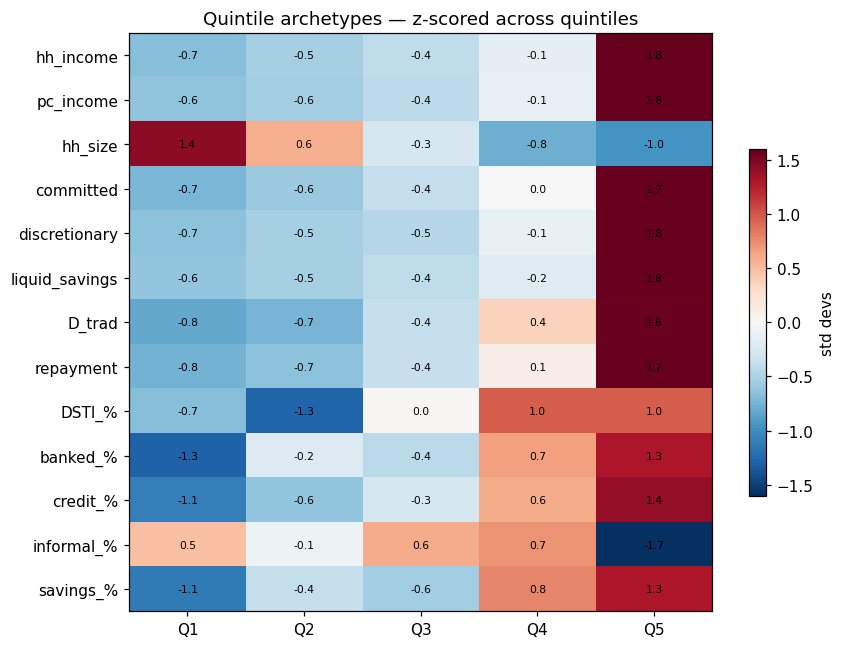

In [4]:
metrics = ["hh_income", "pc_income", "hh_size", "committed", "discretionary", "liquid_savings",
           "D_trad", "repayment", "DSTI_%", "banked_%", "credit_%", "informal_%", "savings_%"]
Z = arch[metrics].copy()
Z = (Z - Z.mean()) / Z.std()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(Z.T.values, cmap="RdBu_r", vmin=-1.6, vmax=1.6, aspect="auto")
ax.set_xticks(range(len(QORDER))); ax.set_xticklabels(QORDER)
ax.set_yticks(range(len(metrics))); ax.set_yticklabels(metrics)
for i in range(len(metrics)):
    for j in range(len(QORDER)):
        ax.text(j, i, f"{Z.T.values[i, j]:.1f}", ha="center", va="center", fontsize=7)
ax.set_title("Quintile archetypes — z-scored across quintiles")
fig.colorbar(im, ax=ax, shrink=0.6, label="std devs"); plt.tight_layout(); plt.show()

## 4. Univariate weighted distributions

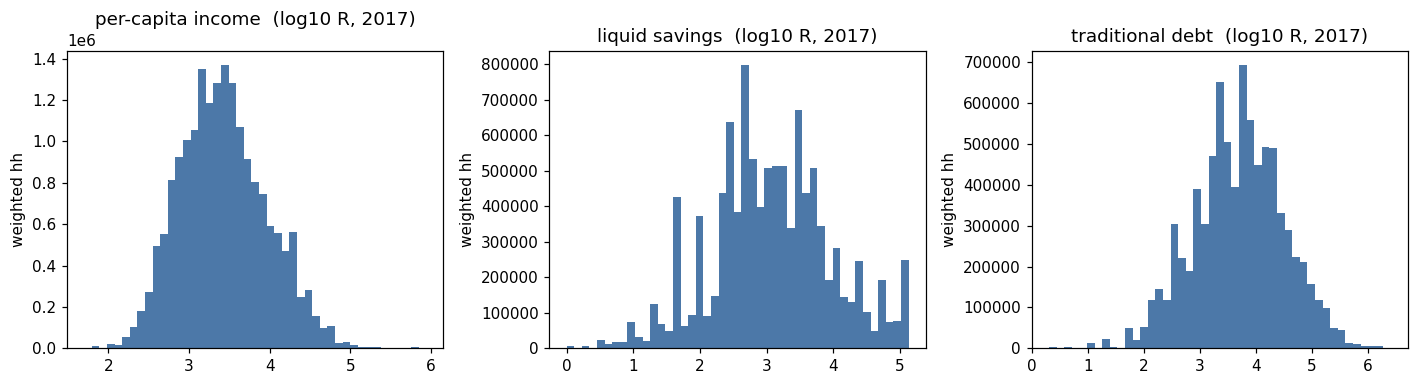

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (col, lab) in zip(axes, [("income_pc", "per-capita income"),
                                 ("liquid_savings", "liquid savings"), ("D_trad", "traditional debt")]):
    x = df[col]; mask = x > 0
    ax.hist(np.log10(x[mask]), bins=45, weights=df.w5_wgt[mask], color="#4C78A8")
    ax.set_title(f"{lab}  (log10 R, 2017)"); ax.set_ylabel("weighted hh")
plt.tight_layout(); plt.show()

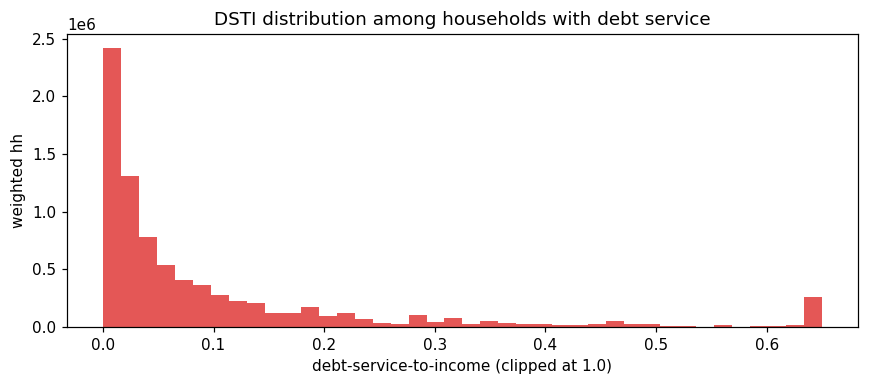

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.6))
d = df[df.dsti > 0]
ax.hist(np.clip(d.dsti, 0, 1.0), bins=40, weights=d.w5_wgt, color="#E45756")
ax.set_xlabel("debt-service-to-income (clipped at 1.0)"); ax.set_ylabel("weighted hh")
ax.set_title("DSTI distribution among households with debt service"); plt.tight_layout(); plt.show()

## 5. Balance sheet & expenditure by quintile

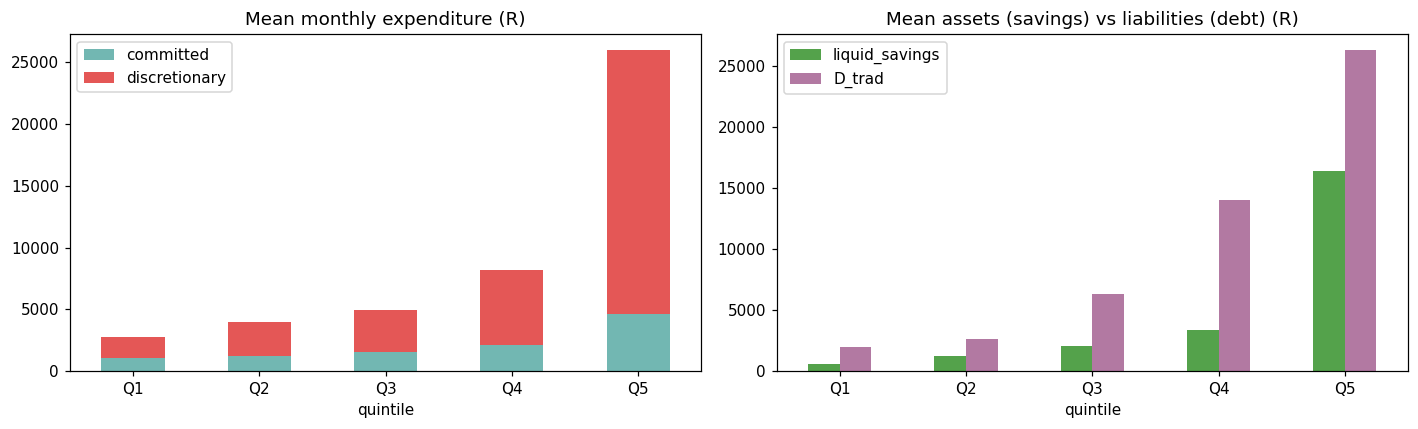

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
arch[["committed", "discretionary"]].plot(kind="bar", stacked=True, ax=axes[0],
                                          color=["#72B7B2", "#E45756"])
axes[0].set_title("Mean monthly expenditure (R)"); axes[0].set_xlabel("quintile")
arch[["liquid_savings", "D_trad"]].plot(kind="bar", ax=axes[1], color=["#54A24B", "#B279A2"])
axes[1].set_title("Mean assets (savings) vs liabilities (debt) (R)"); axes[1].set_xlabel("quintile")
for ax in axes: ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 6. Financial-inclusion flags by quintile

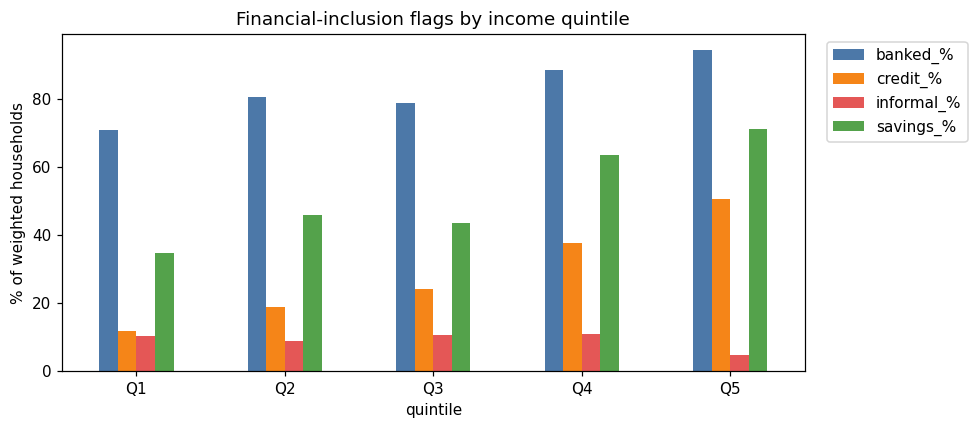

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
arch[["banked_%", "credit_%", "informal_%", "savings_%"]].plot(
    kind="bar", ax=ax, color=["#4C78A8", "#F58518", "#E45756", "#54A24B"])
ax.set_ylabel("% of weighted households"); ax.set_xlabel("quintile")
ax.set_title("Financial-inclusion flags by income quintile")
ax.tick_params(axis="x", rotation=0); ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 7. Income-source composition by quintile

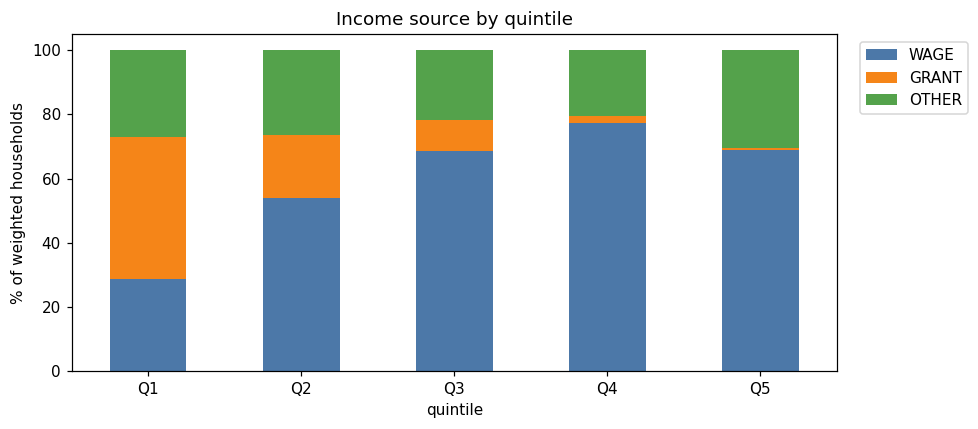

income_source,GRANT,OTHER,WAGE
income_quintile,,,
Q1,44.2,27.0,28.8
Q2,19.6,26.5,53.9
Q3,9.5,21.9,68.6
Q4,2.4,20.4,77.2
Q5,0.5,30.6,69.0


In [9]:
comp = pd.crosstab(df.income_quintile, df.income_source, values=df.w5_wgt, aggfunc="sum", normalize="index") * 100
fig, ax = plt.subplots(figsize=(9, 4))
comp[["WAGE", "GRANT", "OTHER"]].plot(kind="bar", stacked=True, ax=ax,
                                      color={"WAGE": "#4C78A8", "GRANT": "#F58518", "OTHER": "#54A24B"})
ax.set_ylabel("% of weighted households"); ax.set_xlabel("quintile")
ax.set_title("Income source by quintile"); ax.tick_params(axis="x", rotation=0)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left"); plt.tight_layout(); plt.show()
comp.round(1)

## 7b. Head-of-household demographics by quintile

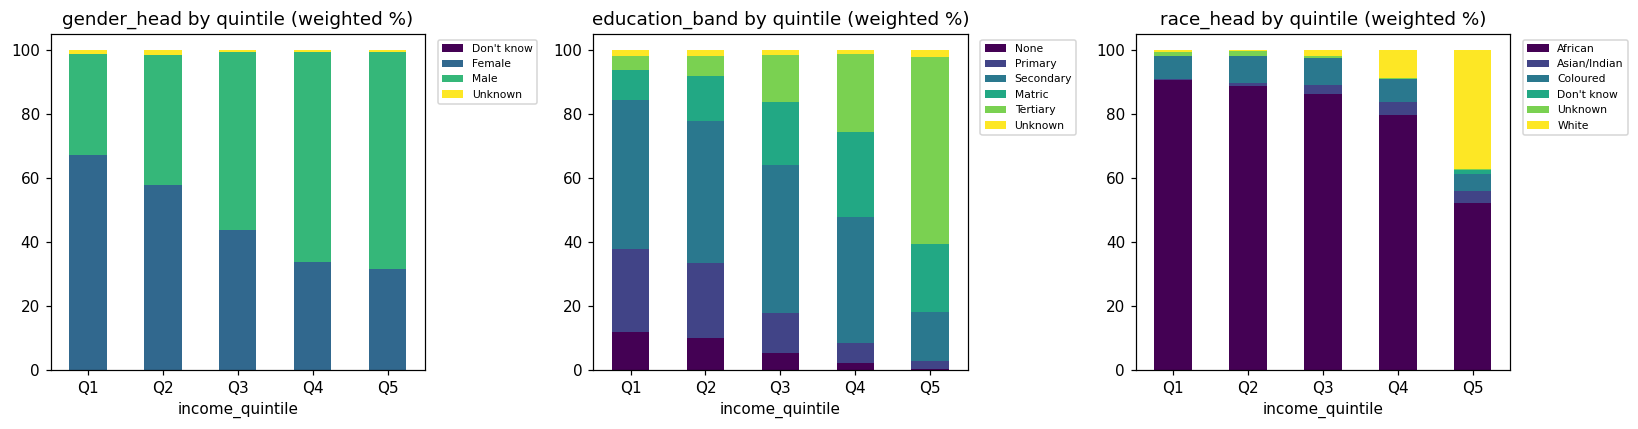

weighted mean head age by quintile:
  Q1: 45.3
  Q2: 45.4
  Q3: 42.0
  Q4: 40.4
  Q5: 44.0


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
specs = [("gender_head", None), ("education_band", ["None","Primary","Secondary","Matric","Tertiary","Unknown"]),
         ("race_head", None)]
for ax, (col, order) in zip(axes, specs):
    ct = pd.crosstab(df.income_quintile, df[col], values=df.w5_wgt, aggfunc="sum", normalize="index") * 100
    if order: ct = ct.reindex(columns=[o for o in order if o in ct.columns])
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
    ax.set_title(f"{col} by quintile (weighted %)"); ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()
print("weighted mean head age by quintile:")
for q, d in df.groupby("income_quintile", observed=True):
    dd = d.dropna(subset=["age_head"]); print(f"  {q}: {np.average(dd.age_head, weights=dd.w5_wgt):.1f}")

## 8. Bivariate structure

A weight-proportional sample of 3,000 households (so the scatter reflects the weighted population),
coloured by quintile.

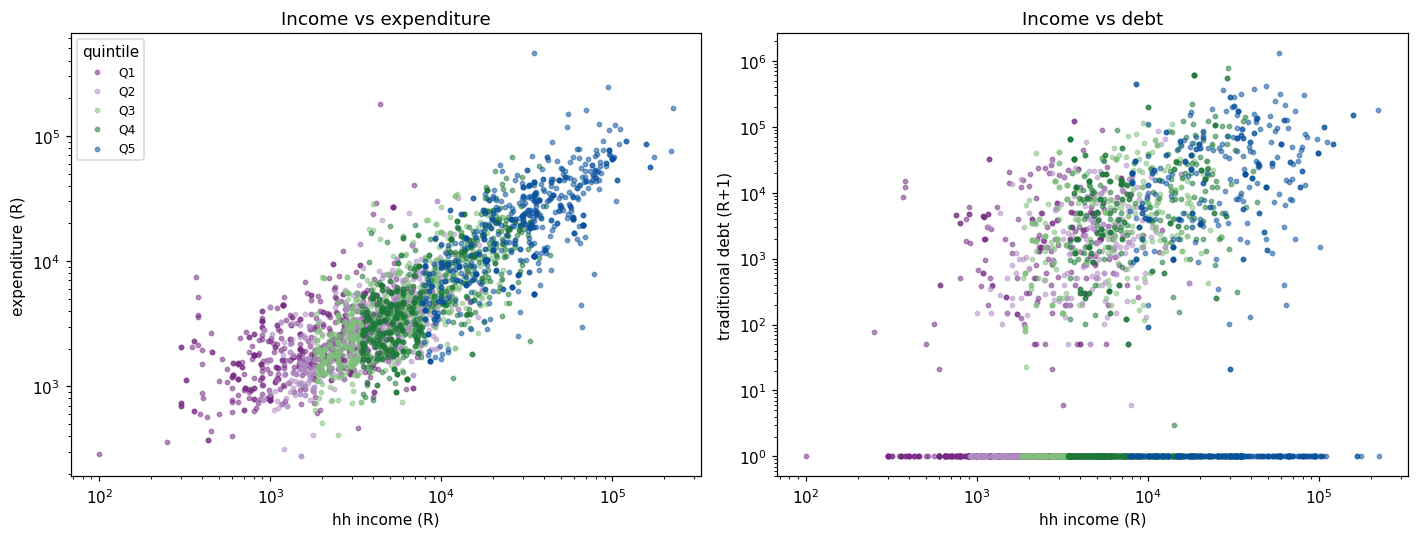

In [11]:
samp = df.sample(3000, weights=df.w5_wgt, random_state=1, replace=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for q in QORDER:
    s = samp[samp.income_quintile == q]
    axes[0].scatter(s.w5_hhincome, s.expenditure_total, s=8, alpha=0.5, color=QCOL[q], label=q)
    axes[1].scatter(s.w5_hhincome, s.D_trad + 1, s=8, alpha=0.5, color=QCOL[q], label=q)
axes[0].set(xscale="log", yscale="log", xlabel="hh income (R)", ylabel="expenditure (R)",
            title="Income vs expenditure")
axes[1].set(xscale="log", yscale="log", xlabel="hh income (R)", ylabel="traditional debt (R+1)",
            title="Income vs debt")
axes[0].legend(title="quintile", fontsize=8); plt.tight_layout(); plt.show()

## 9. Correlation of numeric features

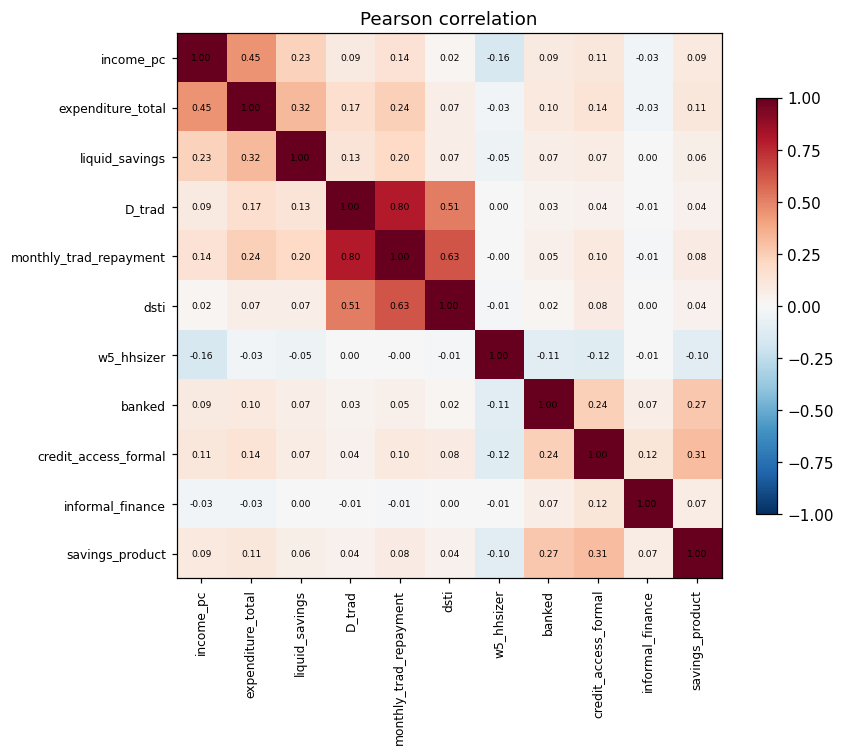

In [12]:
cc = df[["income_pc", "expenditure_total", "liquid_savings", "D_trad", "monthly_trad_repayment",
         "dsti", "w5_hhsizer"] + flags].corr()
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cc.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cc))); ax.set_xticklabels(cc.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(cc))); ax.set_yticklabels(cc.columns, fontsize=8)
for i in range(len(cc)):
    for j in range(len(cc)):
        ax.text(j, i, f"{cc.values[i, j]:.2f}", ha="center", va="center", fontsize=6)
ax.set_title("Pearson correlation"); fig.colorbar(im, ax=ax, shrink=0.7); plt.tight_layout(); plt.show()

## 10. Province view

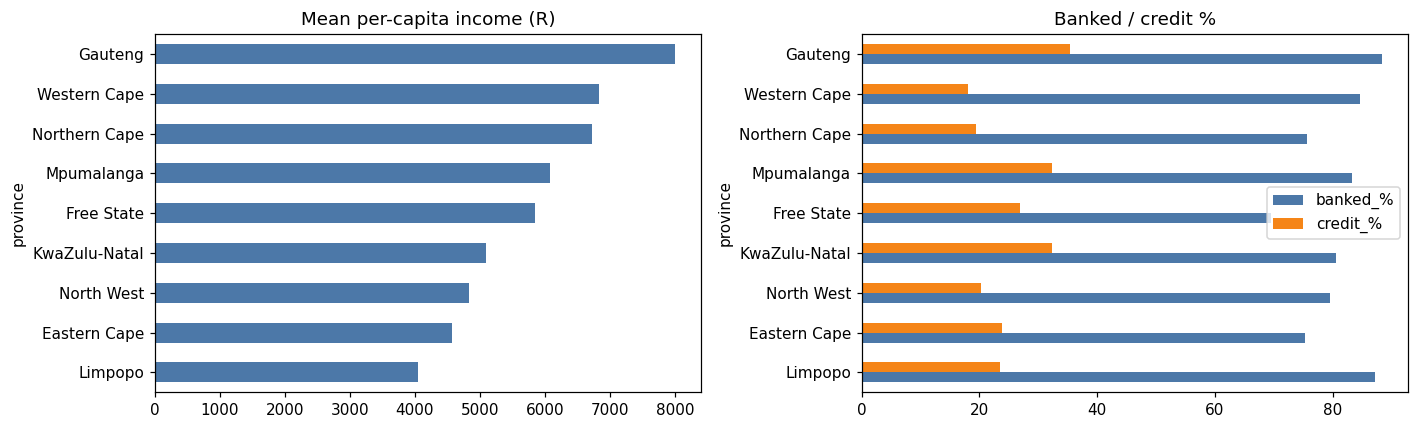

,mean_pc_income,banked_%,credit_%
province,,,
Limpopo,4046.9,87.2,23.6
Eastern Cape,4577.3,75.3,23.9
North West,4826.5,79.5,20.3
KwaZulu-Natal,5087.5,80.5,32.3
Free State,5843.0,69.5,26.9
Mpumalanga,6077.5,83.3,32.3
Northern Cape,6721.7,75.5,19.4
Western Cape,6832.5,84.6,18.1
Gauteng,8003.7,88.4,35.4


In [13]:
prov = df.groupby("province").apply(lambda d: pd.Series({
    "mean_pc_income": wmean(d.income_pc, d.w5_wgt),
    "banked_%": wmean(d.banked, d.w5_wgt) * 100,
    "credit_%": wmean(d.credit_access_formal, d.w5_wgt) * 100,
})).sort_values("mean_pc_income")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
prov["mean_pc_income"].plot(kind="barh", ax=axes[0], color="#4C78A8"); axes[0].set_title("Mean per-capita income (R)")
prov[["banked_%", "credit_%"]].plot(kind="barh", ax=axes[1], color=["#4C78A8", "#F58518"]); axes[1].set_title("Banked / credit %")
plt.tight_layout(); plt.show()
prov.round(1)

## 11. Structure check — is "income quintile" a reasonable way to segment?

Income quintiles are our **chosen** segmentation (a standard policy framing) — **not** a claim that
the data forms natural clusters. As an honest probe we run an *unsupervised* K-means (k=5) and a 2D
PCA projection, **but read them with caution**: PC1+PC2 capture **< 50%** of the variance and
silhouette scores are **weak at every k**. Household financial structure is a **smooth,
income-dominated continuum**, not discrete groups. The takeaway is *how much* of the structure the
quintiles track, not that 5 clusters "exist". Clustering here is **unweighted**.

PC1+PC2 explain 48% of variance | silhouette(k=5) = 0.21  (weak: <0.25 = no crisp clusters)


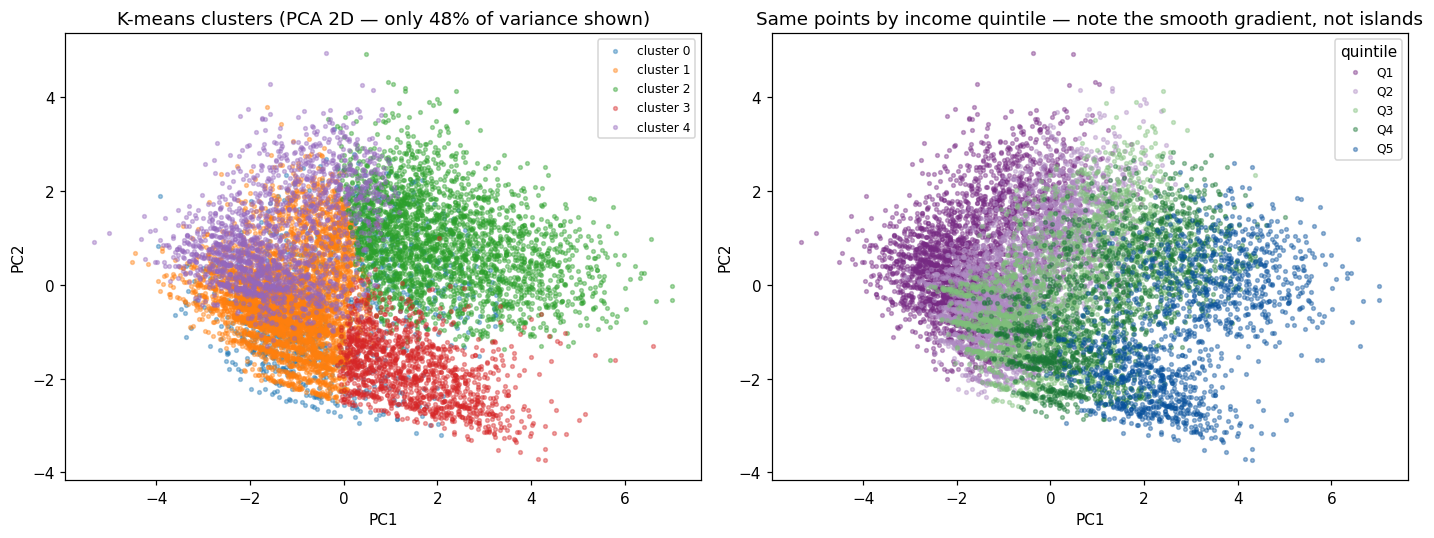

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

feat = pd.DataFrame({
    "log_income": np.log1p(df.w5_hhincome), "log_pc_income": np.log1p(df.income_pc),
    "log_expend": np.log1p(df.expenditure_total), "log_savings": np.log1p(df.liquid_savings),
    "log_debt": np.log1p(df.D_trad), "log_repay": np.log1p(df.monthly_trad_repayment.fillna(0)),
    "hh_size": df.w5_hhsizer, "banked": df.banked, "credit": df.credit_access_formal,
    "informal": df.informal_finance, "savings_flag": df.savings_product})
X = StandardScaler().fit_transform(feat)
km = KMeans(n_clusters=5, n_init=10, random_state=0).fit(X)
df["cluster"] = km.labels_
pca = PCA(random_state=0).fit(X); pcs = pca.transform(X)
evr2 = pca.explained_variance_ratio_[:2].sum()
sil = silhouette_score(X[np.random.RandomState(0).choice(len(X), 3000, replace=False)],
                       km.labels_[np.random.RandomState(0).choice(len(X), 3000, replace=False)])
print(f"PC1+PC2 explain {evr2:.0%} of variance | silhouette(k=5) = {sil:.2f}  (weak: <0.25 = no crisp clusters)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for k in range(5):
    mk = km.labels_ == k
    axes[0].scatter(pcs[mk, 0], pcs[mk, 1], s=6, alpha=0.4, label=f"cluster {k}")
axes[0].set(title=f"K-means clusters (PCA 2D — only {evr2:.0%} of variance shown)", xlabel="PC1", ylabel="PC2")
axes[0].legend(fontsize=8)
for q in QORDER:
    mk = (df.income_quintile == q).values
    axes[1].scatter(pcs[mk, 0], pcs[mk, 1], s=6, alpha=0.4, color=QCOL[q], label=q)
axes[1].set(title="Same points by income quintile — note the smooth gradient, not islands",
            xlabel="PC1", ylabel="PC2"); axes[1].legend(title="quintile", fontsize=8)
plt.tight_layout(); plt.show()

In [15]:
ct = pd.crosstab(df.cluster, df.income_quintile, normalize="index").round(2) * 100
print("cluster × quintile (% of each cluster's households in each quintile):")
print(ct.to_string())
print("\nReading: clusters smear across adjacent quintiles rather than mapping 1:1 — consistent with")
print("a continuum. One cluster concentrates in Q4/Q5 (the affluent tail); the rest overlap in the")
print("lower-middle. Quintiles capture the income axis; within-quintile savings/credit variation remains.")

cluster × quintile (% of each cluster's households in each quintile):
income_quintile    Q1    Q2    Q3    Q4    Q5
cluster                                      
0                32.0  29.0  23.0  14.0   3.0
1                41.0  34.0  18.0   7.0   0.0
2                 6.0  19.0  23.0  26.0  26.0
3                 0.0   3.0  12.0  32.0  54.0
4                48.0  27.0  20.0   5.0   0.0

Reading: clusters smear across adjacent quintiles rather than mapping 1:1 — consistent with
a continuum. One cluster concentrates in Q4/Q5 (the affluent tail); the rest overlap in the
lower-middle. Quintiles capture the income axis; within-quintile savings/credit variation remains.


## Summary

- The five income quintiles are a **chosen, defensible segmentation** of a smooth income-driven
  continuum — the data does **not** contain crisp natural clusters (weak silhouette, PCA < 50%).
- The z-scored archetype fingerprint (§3a) shows the income/expenditure/credit gradient and the
  grant→wage source shift; saved to `data/processed/quintile_archetypes.csv`.
- Formal validation (benchmark comparisons, pass/fail) lives in `p4_validation.ipynb`.
- Next: **P3** (weighted resample to 5,000).